In [1]:
import os
os.environ["PYTHONWARNING"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [4]:
sc.settings.set_figure_params(frameon=False, fontsize=10, vector_friendly=True)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("quiescence", ["#2FBF71", "#8C8C8C", "#6A5ACD"], N=256)

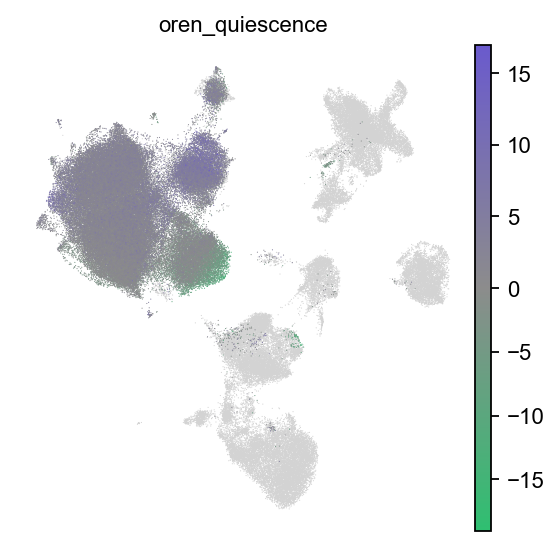

In [8]:
sc.pl.umap(adata_full, color="oren_quiescence", cmap=cmap, vcenter=0, size=1, save="_quiescence_score.pdf")

In [9]:
adata_cancer = adata_full[adata_full.obs["type"] != "normal"].copy()

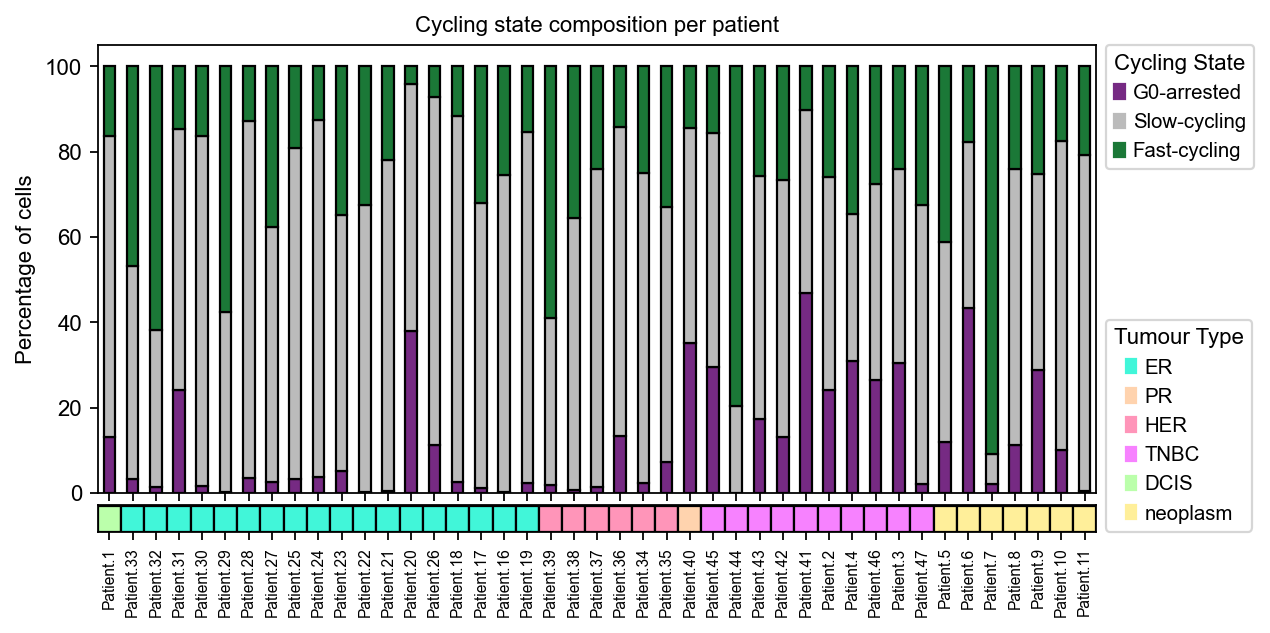

In [10]:
# Custom cycling state colours
group_colors = {
    "G0-arrested": "#762A83",
    "Slow-cycling": "#BBBBBB",
    "Fast-cycling": "#1B7837",
}
type_colors = {
    "ER": "#41F6D9",
    "PR": "#FFD3AE",
    "HER": "#FF95B9",
    "TNBC": "#F782FF",
    "DCIS": "#BBFFAB",
    "neoplasm": "#FFEF9A",
}

# Count table: patient × cycling state
count_df = pd.crosstab(adata_cancer.obs["patient"], adata_cancer.obs["cycling_state_oren"])
count_df = count_df[[k for k in group_colors if k in count_df.columns]]

# Tumour type per patient (one type per patient)
patient_to_type = (
    adata_cancer.obs[["patient", "type"]]
    .drop_duplicates()
    .groupby("patient")["type"]
    .first()
)

# Add type column and sort by it
count_df["type"] = patient_to_type.loc[count_df.index]
count_df_sorted = count_df.sort_values("type")
type_labels = count_df_sorted["type"]
count_df_sorted = count_df_sorted.drop(columns="type")

# Convert counts to percentages
percentage_df = count_df_sorted.div(count_df_sorted.sum(axis=1), axis=0) * 100

# Setup figure with two rows (type bar and main plot)
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 4),
    height_ratios=[5, 0.3],
    sharex=True,
    gridspec_kw={"hspace": 0.05},
)

# Plot cycling states stacked bar
percentage_df.plot(
    kind="bar",
    stacked=True,
    color=[group_colors[col] for col in percentage_df.columns],
    edgecolor="black",
    ax=axes[0],
)
axes[0].set_ylabel("Percentage of cells")
axes[0].set_title("Cycling state composition per patient")
axes[0].set_xticks([])
axes[0].grid(False)

# Plot tumour type coloured bar
for i, label in enumerate(type_labels):
    axes[1].bar(i, 1, color=type_colors[label], edgecolor="black", width=1.0)
axes[1].set_yticks([])
axes[1].set_xticks(range(len(type_labels)))
axes[1].set_xticklabels(type_labels.index, rotation=90, fontsize=7)

# Create legend handles for cycling states and tumour types
cycling_handles = [
    mpatches.Patch(color=col, label=state) for state, col in group_colors.items()
]
type_handles = [
    mpatches.Patch(color=col, label=typ) for typ, col in type_colors.items()
]

# Place legends side by side outside the plot on the right
axes[0].legend(
    handles=cycling_handles,
    title="Cycling State",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)

axes[1].legend(
    handles=type_handles,
    title="Tumour Type",
    bbox_to_anchor=(1.01, 0),
    loc="lower left",
    borderaxespad=0,
)

plt.tight_layout()
plt.grid(False)
plt.savefig(figure_dir + "patient_cycling_state_composition.pdf", bbox_inches="tight")
plt.show()

LumA (Fast-cycling < 20.0%): 9 patients
LumB (Fast-cycling ≥ 20.0%): 9 patients


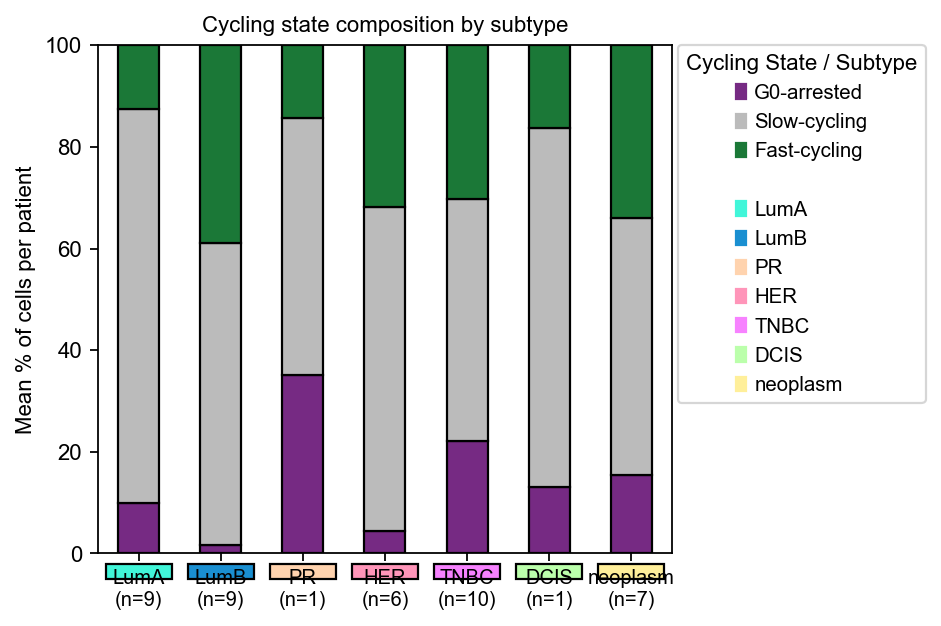

In [17]:
# Custom cycling state colours
group_colors = {
    "G0-arrested": "#762A83",
    "Slow-cycling": "#BBBBBB",
    "Fast-cycling": "#1B7837",
}
type_colors = {
    "LumA": "#41F6D9",
    "LumB": "#1A8FD1",
    "PR": "#FFD3AE",
    "HER": "#FF95B9",
    "TNBC": "#F782FF",
    "DCIS": "#BBFFAB",
    "neoplasm": "#FFEF9A",
}

# ── Step 1: classify ER+ patients into LumA / LumB ──────────────────────────
# Use only malignant cells so stromal contamination doesn't skew Fast-cycling %

adata_malignant = adata_cancer[adata_cancer.obs["malignancy"] == "malignant"]

malignant_counts = pd.crosstab(
    adata_malignant.obs["patient"], adata_malignant.obs["cycling_state_oren"]
)
malignant_counts = malignant_counts[
    [k for k in group_colors if k in malignant_counts.columns]
]
malignant_pct = malignant_counts.div(malignant_counts.sum(axis=1), axis=0) * 100

patient_to_type = (
    adata_cancer.obs[["patient", "type"]]
    .drop_duplicates()
    .groupby("patient")["type"]
    .first()
)

er_patients = patient_to_type[patient_to_type == "ER"].index
er_fast_pct = malignant_pct.loc[
    er_patients.intersection(malignant_pct.index), "Fast-cycling"
]

LUMB_THRESHOLD = 20.0  # Ki67 proxy: >= 20% Fast-cycling → LumB
luma_patients = er_fast_pct[er_fast_pct < LUMB_THRESHOLD].index
lumb_patients = er_fast_pct[er_fast_pct >= LUMB_THRESHOLD].index

print(f"LumA (Fast-cycling < {LUMB_THRESHOLD}%): {len(luma_patients)} patients")
print(f"LumB (Fast-cycling ≥ {LUMB_THRESHOLD}%): {len(lumb_patients)} patients")

patient_subtype = patient_to_type.copy().astype(str)
patient_subtype.loc[luma_patients] = "LumA"
patient_subtype.loc[lumb_patients] = "LumB"

# ── Step 2: build per-patient cycling state % from all cancer cells ──────────

count_df = pd.crosstab(
    adata_cancer.obs["patient"], adata_cancer.obs["cycling_state_oren"]
)
count_df = count_df[[k for k in group_colors if k in count_df.columns]]
pct_df = count_df.div(count_df.sum(axis=1), axis=0) * 100

# ── Step 3: aggregate mean cycling state % per subtype ───────────────────────

pct_df["subtype"] = patient_subtype.loc[pct_df.index]
subtype_mean = pct_df.groupby("subtype")[[*group_colors]].mean()

subtype_order = [
    s
    for s in ["LumA", "LumB", "PR", "HER", "TNBC", "DCIS", "neoplasm"]
    if s in subtype_mean.index
]
subtype_mean = subtype_mean.loc[subtype_order]
subtype_n = pct_df["subtype"].value_counts()

# ── Step 4: plot ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4))

subtype_mean.plot(
    kind="bar",
    stacked=True,
    color=[group_colors[col] for col in subtype_mean.columns],
    edgecolor="black",
    ax=ax,
)

ax.set_ylabel("Mean % of cells per patient")
ax.set_title("Cycling state composition by subtype")
ax.set_xlabel("")
ax.set_xticklabels(
    [f"{s}\n(n={subtype_n.get(s, 0)})" for s in subtype_order],
    rotation=0,
    fontsize=9,
)
ax.set_ylim(0, 100)
ax.grid(False)

# Subtype colour strip below bars
for i, s in enumerate(subtype_order):
    ax.bar(
        i,
        3,
        bottom=-5,
        color=type_colors[s],
        edgecolor="black",
        width=0.8,
        clip_on=False,
    )

cycling_handles = [
    mpatches.Patch(color=col, label=state) for state, col in group_colors.items()
]
type_handles = [mpatches.Patch(color=type_colors[s], label=s) for s in subtype_order]

ax.legend(
    handles=cycling_handles + [mpatches.Patch(visible=False, label="")] + type_handles,
    title="Cycling State / Subtype",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.savefig(figure_dir + "subtype_cycling_state_composition.pdf", bbox_inches="tight")
plt.show()


In [17]:
adata_tumour = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()
adata_tumour.X = adata_tumour.layers["counts"].copy()
sc.pp.filter_genes(adata_tumour, min_cells=20)
sc.pp.normalize_total(adata_tumour, target_sum=1e4)
adata_tumour.X = np.log1p(adata_tumour.X)

filtered out 590 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)


In [35]:
sc.tl.rank_genes_groups(
    adata_tumour, groupby="cycling_state_oren", method="wilcoxon", use_raw=False
)

ranking genes
    finished (0:04:49)


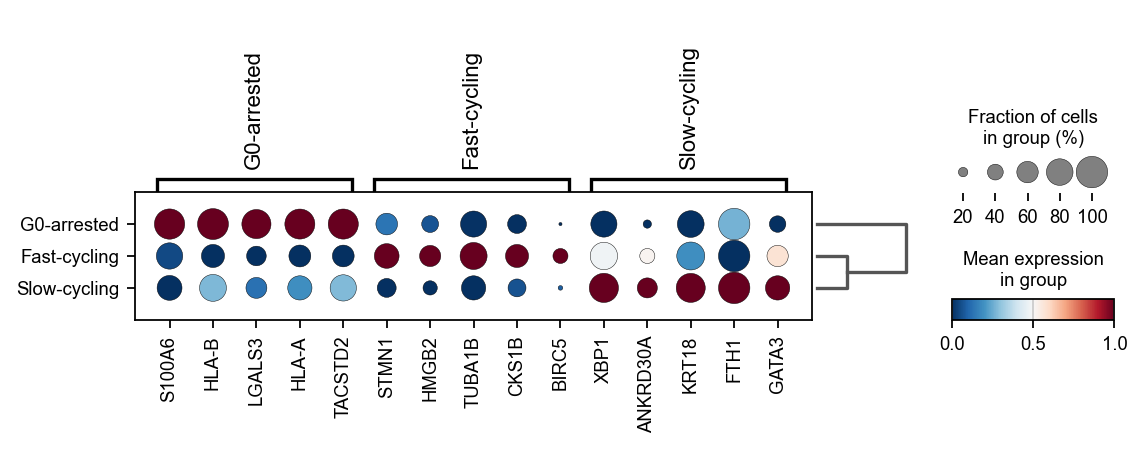

In [40]:
sc.pl.rank_genes_groups_dotplot(
    adata_tumour,
    n_genes=5,
    groupby="cycling_state_oren",
    cmap="RdBu_r",
    standard_scale="var",
    key="rank_genes_groups",
    save="cycling_states_top_genes_dotplot.pdf",
)

In [13]:
adata_epi = adata_full[adata_full.obs["cellclass"] == "EPI"].copy()

In [14]:
adata_epi.X = adata_epi.layers["counts"].copy()
sc.pp.filter_genes(adata_epi, min_cells=20)
sc.pp.normalize_total(adata_epi, target_sum=1e4)
adata_epi.X = np.log1p(adata_epi.X)
sc.pp.highly_variable_genes(adata_epi, n_top_genes=2000, flavor="cell_ranger", batch_key="patient")

filtered out 508 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:11)


In [15]:
sc.pp.pca(adata_epi, use_highly_variable=True)
sc.external.pp.harmony_integrate(adata_epi, key="patient")

computing PCA
    with n_comps=50
    finished (0:00:11)


2025-12-19 18:31:29,003 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-19 18:31:36,602 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-19 18:31:37,090 - harmonypy - INFO - Iteration 1 of 10
2025-12-19 18:32:30,145 - harmonypy - INFO - Iteration 2 of 10
2025-12-19 18:33:18,660 - harmonypy - INFO - Iteration 3 of 10
2025-12-19 18:34:10,334 - harmonypy - INFO - Iteration 4 of 10
2025-12-19 18:34:59,332 - harmonypy - INFO - Converged after 4 iterations


In [16]:
sc.pp.neighbors(adata_epi, use_rep="X_pca_harmony", n_neighbors=30, n_pcs=30)
sc.tl.umap(adata_epi)

computing neighbors
    finished (0:00:47)
computing UMAP
    finished (0:02:02)


In [17]:
adata_epi.uns["malignancy_colors"] = ["#CF77FF", "#EBEBEB"]

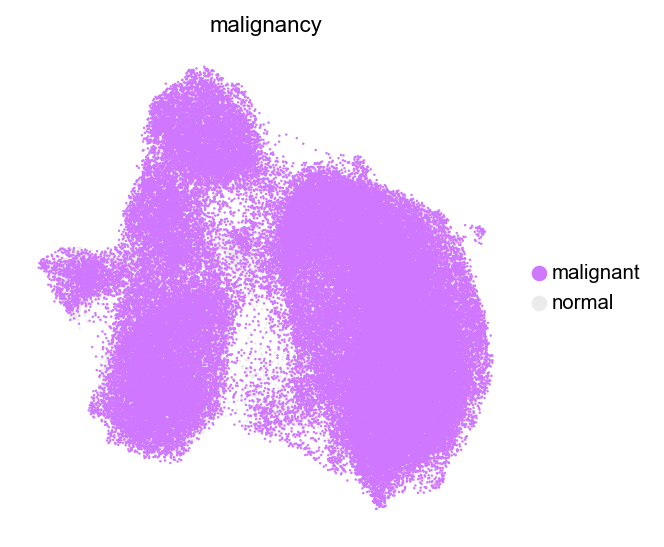

In [18]:
sc.pl.umap(adata_epi, color="malignancy", size=5, save="_epithelial.pdf")

In [19]:
adata_epi.uns["type_colors"] = [
    "#BBFFAB",
    "#41F6D9",
    "#FF95B9",
    "#FFD3AE",
    "#F782FF",
    "#FFEF9A",
    "#D6D6D6",
]

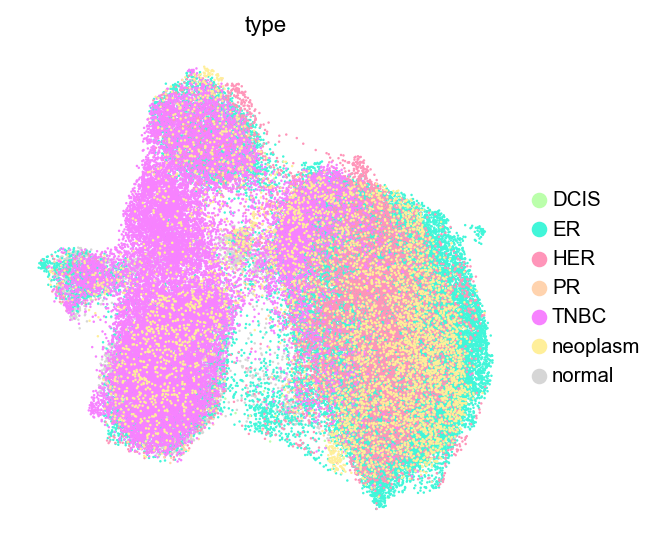

In [20]:
sc.pl.umap(adata_epi, color="type", size=5, save="_type.pdf")

In [21]:
adata_tumour = adata_epi[adata_epi.obs["malignancy"] == "malignant"].copy()

adata_tumour.X = adata_tumour.layers["counts"].copy()
sc.pp.filter_genes(adata_tumour, min_cells=20)
sc.pp.normalize_total(adata_tumour, target_sum=1e4)
adata_tumour.X = np.log1p(adata_tumour.X)
sc.pp.highly_variable_genes(adata_tumour, n_top_genes=2000, flavor="cell_ranger", batch_key="patient")

filtered out 82 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:10)


In [22]:
sc.pp.pca(adata_tumour, use_highly_variable=True)
sc.external.pp.harmony_integrate(adata_tumour, key="patient")

computing PCA
    with n_comps=50
    finished (0:00:10)


2025-12-19 18:38:36,962 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-12-19 18:38:43,746 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-19 18:38:44,196 - harmonypy - INFO - Iteration 1 of 10
2025-12-19 18:39:26,896 - harmonypy - INFO - Iteration 2 of 10
2025-12-19 18:40:10,357 - harmonypy - INFO - Converged after 2 iterations


In [23]:
sc.pp.neighbors(adata_tumour, use_rep="X_pca_harmony", n_neighbors=30, n_pcs=30)
sc.tl.umap(adata_tumour)

computing neighbors
    finished (0:00:15)
computing UMAP
    finished (0:01:33)


In [24]:
adata_tumour.uns["cycling_state_oren_colors"] = [
    "#2FBF71",
    "#6A5ACD",
    "#8C8C8C",
]

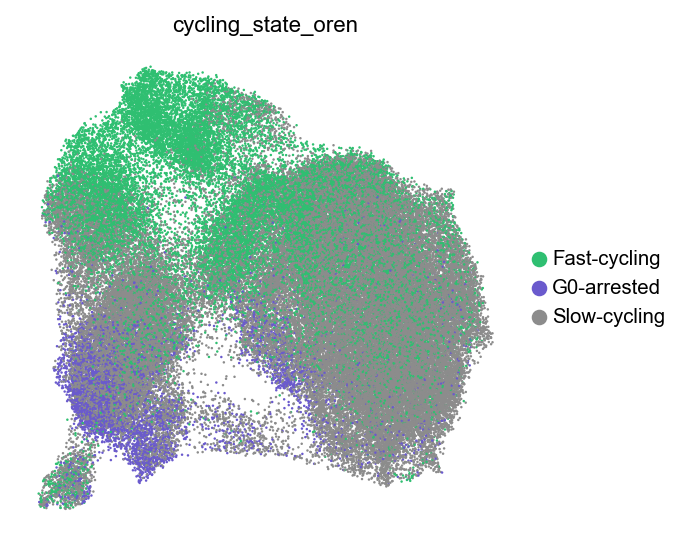

In [25]:
sc.pl.umap(adata_tumour, color="cycling_state_oren", size=5, save="_cycling_state.pdf")

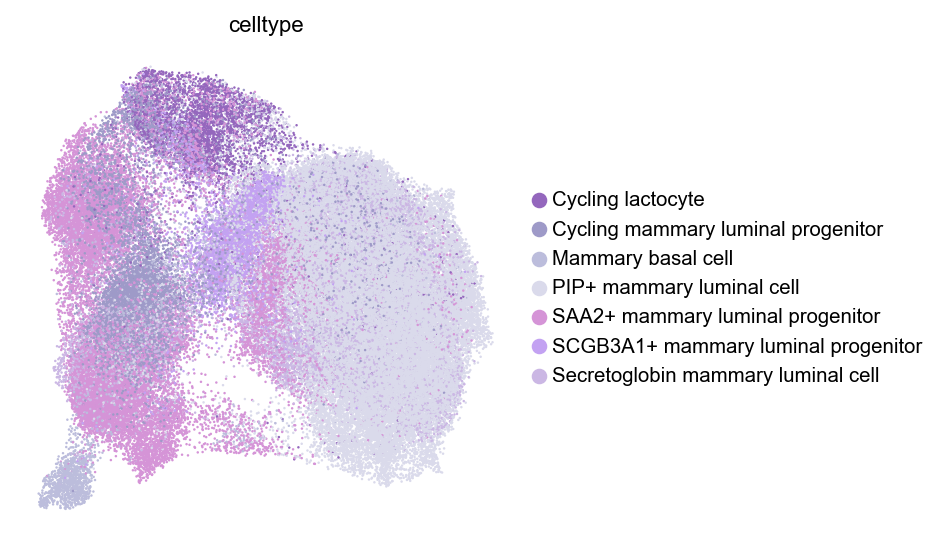

In [26]:
sc.pl.umap(adata_tumour, color="celltype", size=5, save="_tumour_celltype.pdf")

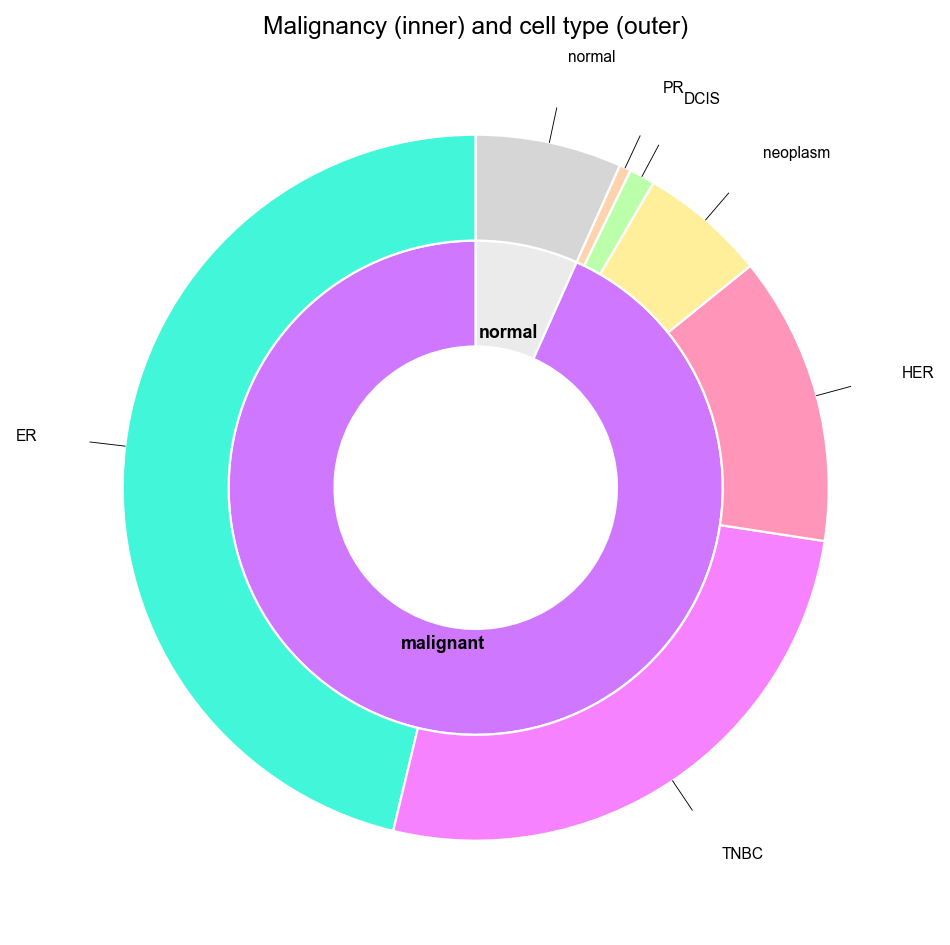

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

malignancy_colors = adata_epi.uns["malignancy_colors"]
type_colors = adata_epi.uns["type_colors"]

df = adata_epi.obs[["malignancy", "type"]].copy()

# Colour lookup tables (categorical order)
malignancy_levels = adata_epi.obs["malignancy"].cat.categories.tolist()
type_levels = adata_epi.obs["type"].cat.categories.tolist()

malignancy_color_map = dict(zip(malignancy_levels, malignancy_colors))
type_color_map = dict(zip(type_levels, type_colors))

# Proportions
prop_malignancy = df["malignancy"].value_counts(normalize=True)
prop_type = df["type"].value_counts(normalize=True)


# Enforce ordering: move "normal" to the end
def move_normal_to_end(index):
    idx = [x for x in index if x != "normal"]
    if "normal" in index:
        idx.append("normal")
    return idx


inner_labels = move_normal_to_end(prop_malignancy.index.tolist())
outer_labels = move_normal_to_end(prop_type.index.tolist())

inner_fracs = prop_malignancy.loc[inner_labels].values
outer_fracs = prop_type.loc[outer_labels].values

inner_colors = [malignancy_color_map[m] for m in inner_labels]
outer_colors = [type_color_map[t] for t in outer_labels]

# Plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")

# Inner donut: malignancy
wedges_inner, _ = ax.pie(
    inner_fracs,
    radius=0.7,
    startangle=90,
    colors=inner_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Outer donut: type
wedges_outer, _ = ax.pie(
    outer_fracs,
    radius=1.0,
    startangle=90,
    colors=outer_colors,
    wedgeprops=dict(width=0.3, edgecolor="white"),
)

# Inner labels
for wedge, label in zip(wedges_inner, inner_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 0.45 * np.cos(np.deg2rad(angle))
    y = 0.45 * np.sin(np.deg2rad(angle))
    ax.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")

# Outer labels
for wedge, label in zip(wedges_outer, outer_labels):
    angle = (wedge.theta1 + wedge.theta2) / 2
    x = 1.25 * np.cos(np.deg2rad(angle))
    y = 1.25 * np.sin(np.deg2rad(angle))
    ha = "left" if x > 0 else "right"
    ax.text(x, y, label, ha=ha, va="center", fontsize=7)
    ax.plot(
        [np.cos(np.deg2rad(angle)), 1.1 * np.cos(np.deg2rad(angle))],
        [np.sin(np.deg2rad(angle)), 1.1 * np.sin(np.deg2rad(angle))],
        color="black",
        lw=0.4,
    )

ax.set_title("Malignancy (inner) and cell type (outer)", fontsize=11)

plt.tight_layout()
plt.savefig(f"{figure_dir}/nested_donut_malignancy_type.pdf", bbox_inches="tight")
plt.show()

In [28]:
adata_tumour.write_h5ad(data_dir + "adata_tumour.h5ad")